# Klasifikasi Huruf Bahasa Isyarat BISINDO Menggunakan Metode K-Nearest Neighbor (K-NN) Berbasis Ekstraksi Fitur Citra


In [ ]:
!pip install opendatasets

In [ ]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/meisyavira/abjad-bahasa-isyarat-indonesia-bisindo")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: bondantm
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/meisyavira/abjad-bahasa-isyarat-indonesia-bisindo


100%|██████████| 155M/155M [00:00<00:00, 401MB/s]


In [ ]:
import os
import cv2
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from skimage.feature import hog # Library yang powerful untuk HOG
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler # Penting untuk HOG dan K-NN
from tqdm import tqdm

In [ ]:
# --- 1. Konfigurasi Direktori & Variabel Global ---
# Ganti path ini sesuai dengan struktur folder hasil download Kaggle
DATA_DIR = '/content/abjad-bahasa-isyarat-indonesia-bisindo/dataset_merged'
# Parameter anda
IMG_SIZE = (150, 150)
TEST_SIZE = 0.1
K_VALUE = 3

# Parameter HOG
PIXELS_PER_CELL = (16, 16)
CELLS_PER_BLOCK = (2, 2)
ORIENTATIONS = 9

In [ ]:
# Menganalisis Struktur Folder
# Dapatkan daftar semua sub-folder/kelas (misalnya, A, B, C, dst.)
class_names = sorted(os.listdir(DATA_DIR))
class_paths = [os.path.join(DATA_DIR, name) for name in class_names]

# Buat kamus untuk menyimpan hitungan dan sampel path
data_summary = {}
sample_paths = {}

for class_name, class_path in zip(class_names, class_paths):
    # Cari semua file gambar (misalnya, .jpg atau .png) di dalam folder
    image_files = glob.glob(os.path.join(class_path, '*.*'))

    count = len(image_files)

    # Simpan hitungan
    data_summary[class_name] = count

    # Simpan satu path sampel jika ada gambar
    if count > 0:
        sample_paths[class_name] = random.choice(image_files)
    else:
        sample_paths[class_name] = None

print("✅ Analisis Folder Selesai.")
print("-" * 40)
print("Ringkasan Jumlah Gambar per Kelas:")
for name, count in data_summary.items():
    print(f"- {name}: {count} gambar")

✅ Analisis Folder Selesai.
----------------------------------------
Ringkasan Jumlah Gambar per Kelas:
- A: 25 gambar
- B: 25 gambar
- C: 25 gambar
- D: 25 gambar
- E: 25 gambar
- F: 25 gambar
- G: 25 gambar
- H: 25 gambar
- I: 25 gambar
- J: 25 gambar
- K: 25 gambar
- L: 25 gambar
- M: 25 gambar
- N: 25 gambar
- O: 25 gambar
- P: 25 gambar
- Q: 25 gambar
- R: 25 gambar
- S: 25 gambar
- T: 25 gambar
- U: 25 gambar
- V: 25 gambar
- W: 25 gambar
- X: 25 gambar
- Y: 25 gambar
- Z: 25 gambar


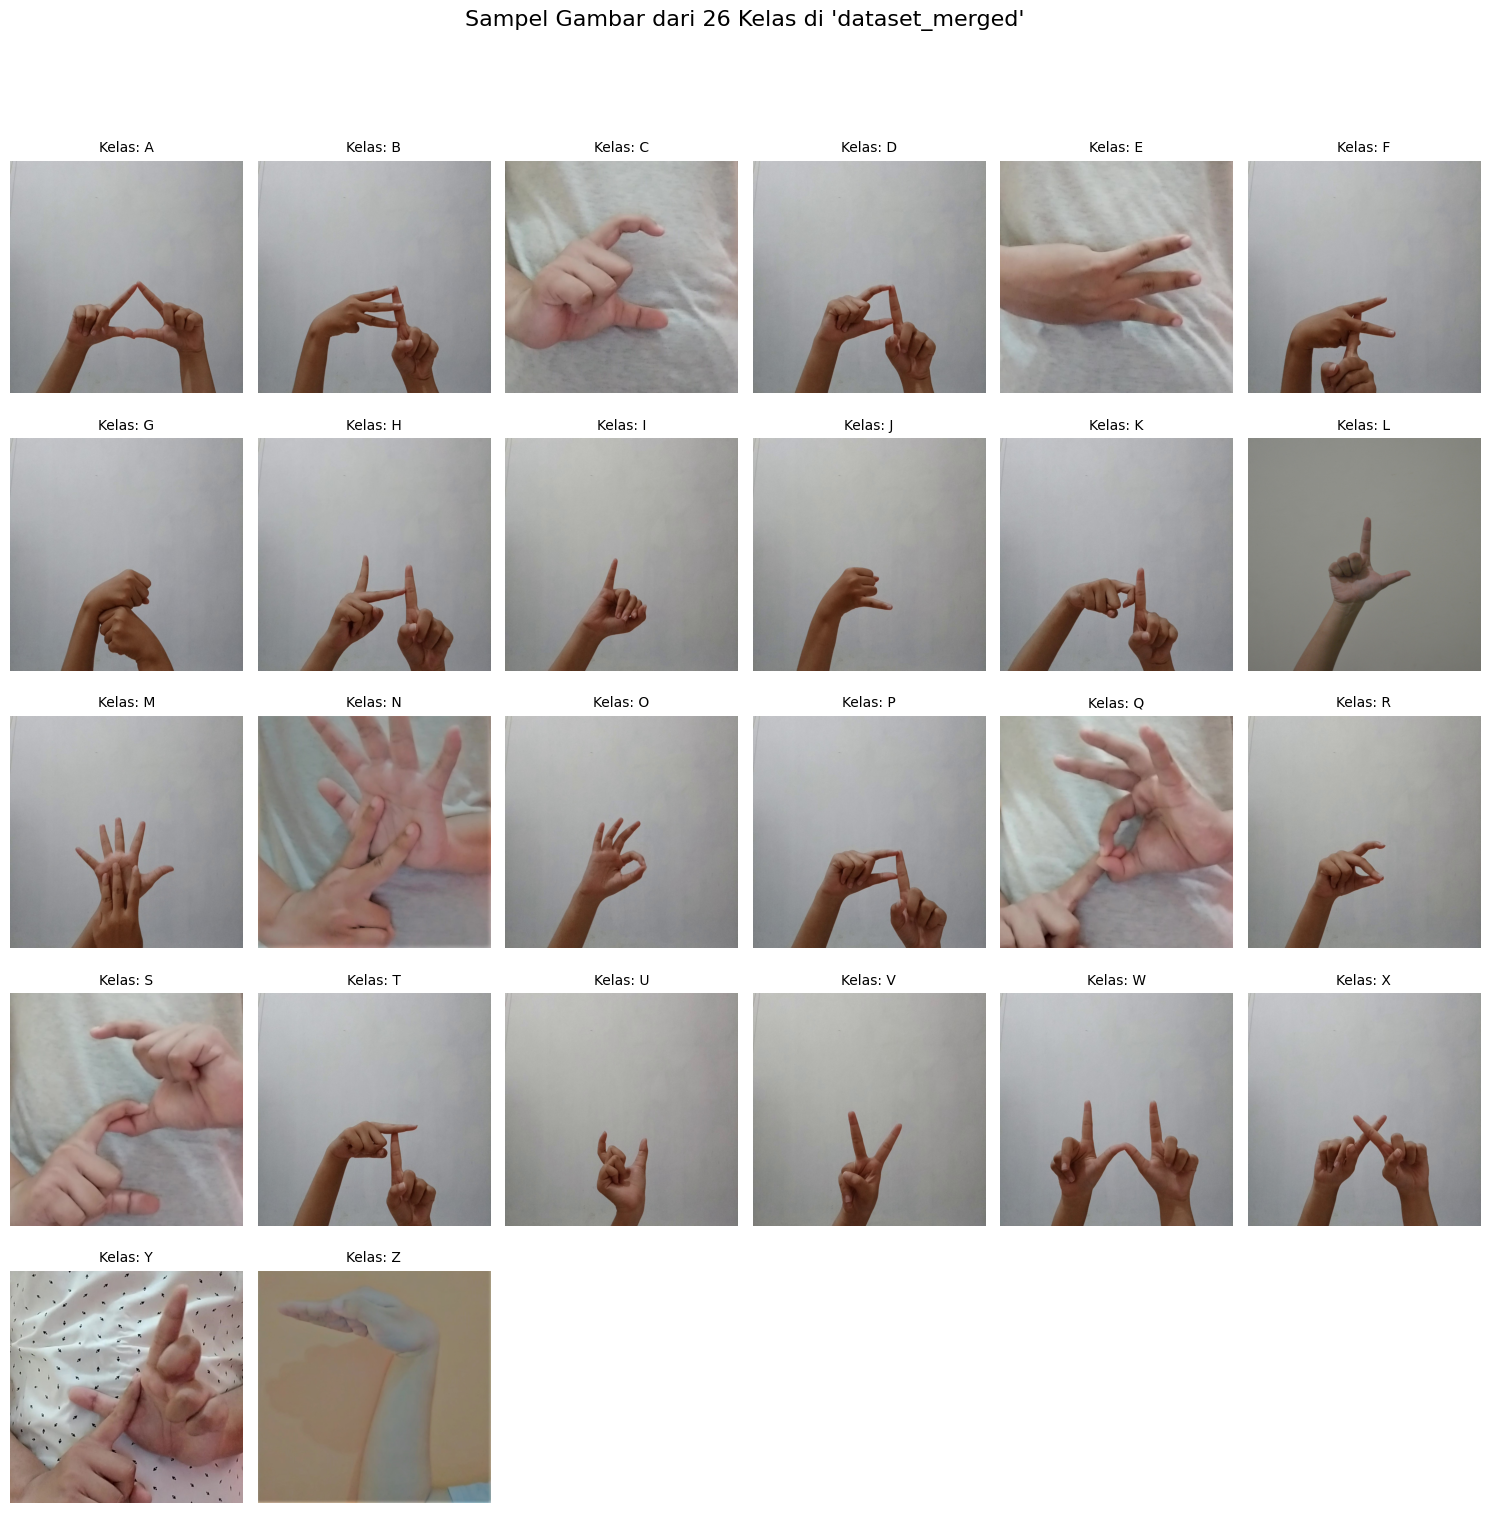

In [ ]:
# Visualisasi Sampel Gambar

# Tentukan tata letak grid untuk plot (misalnya, 6 kolom)
n_classes = len(sample_paths)
ncols = 6
nrows = (n_classes + ncols - 1) // ncols

plt.figure(figsize=(15, 3 * nrows))
plt.suptitle(f"Sampel Gambar dari {n_classes} Kelas di '{os.path.basename(DATA_DIR)}'", fontsize=16, y=1.02)

for i, (class_name, img_path) in enumerate(sample_paths.items()):
    if img_path:
        plt.subplot(nrows, ncols, i + 1)

        try:
            # Baca gambar
            img = mpimg.imread(img_path)

            # Tampilkan gambar
            plt.imshow(img)
            plt.title(f"Kelas: {class_name}", fontsize=10)
            plt.axis('off')

        except Exception as e:
            plt.title(f"ERROR: {class_name}", fontsize=10)
            plt.text(0.5, 0.5, "Gagal Memuat", ha='center', va='center', color='red')
            plt.axis('off')

plt.tight_layout(rect=[0, 0, 1, 1-0.03])
plt.show()

In [ ]:
# --- Fungsi Segmentasi Berbasis Warna Kulit ---

def segment_skin_color(img):
    """
    Melakukan segmentasi menggunakan ruang warna YCrCb untuk deteksi kulit.
    1. Konversi ke YCrCb
    2. Masking/Thresholding pada komponen Cr dan Cb
    3. Noise Removal (Morphology)
    """

    # 1. Konversi BGR ke YCrCb
    ycrcb_img = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)

    # 2. Masking/Thresholding
    # Rentang standar untuk deteksi kulit manusia dalam YCrCb:
    # Y (Luminance) biasanya diabaikan agar robust terhadap cahaya
    # Cr (Red-difference): 133 - 173
    # Cb (Blue-difference): 77 - 127
    lower_skin = np.array([0, 133, 77], dtype=np.uint8)
    upper_skin = np.array([255, 173, 127], dtype=np.uint8)

    mask = cv2.inRange(ycrcb_img, lower_skin, upper_skin)

    # 3. Noise Removal (Morfologi)
    # Menggunakan kernel untuk membersihkan bintik-bintik putih kecil (noise)
    kernel = np.ones((3, 3), np.uint8)

    # Opening: Menghilangkan noise (bintik putih) di latar belakang
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)

    # Closing: Menutup lubang kecil di dalam objek tangan
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)

    # Mengambil kontur terbesar untuk memastikan hanya tangan yang diambil
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    final_mask = np.zeros_like(mask)

    if contours:
        c = max(contours, key=cv2.contourArea)
        cv2.drawContours(final_mask, [c], 0, 255, -1)

    return final_mask

In [ ]:
# --- Fungsi Utama Load dan Ekstraksi Fitur HOG ---

def load_data_and_extract_features(data_directory):
    print("Memulai pemuatan (YCrCb), segmentasi, dan ekstraksi fitur HOG...")
    all_features = []
    all_labels = []

    # Pastikan dictionary untuk visualisasi sudah siap
    global example_images
    example_images = {}

    for label in sorted(os.listdir(data_directory)):
        label_dir = os.path.join(data_directory, label)
        if not os.path.isdir(label_dir):
            continue

        print(f"Memproses kelas: {label}")

        for filename in tqdm(os.listdir(label_dir)):
            img_path = os.path.join(label_dir, filename)
            img = cv2.imread(img_path)

            if img is None: continue

            # 1. Preprocessing: Resize
            resized_img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)

            # 2. Segmentasi menggunakan YCrCb (Memanggil fungsi yang sudah dibuat sebelumnya)
            # Fungsi ini mengembalikan mask biner
            mask = segment_skin_color(resized_img)

            # 3. Konversi Citra ke YCrCb untuk Ekstraksi Fitur
            ycrcb_img = cv2.cvtColor(resized_img, cv2.COLOR_BGR2YCrCb)

            # Kita gunakan komponen Luminance (Y) atau Cr yang sudah di-masking
            # Menggunakan Y yang di-masking biasanya memberikan detail tekstur tangan yang lebih baik
            y_channel, cr_channel, cb_channel = cv2.split(ycrcb_img)
            masked_component = cv2.bitwise_and(y_channel, y_channel, mask=mask)

            # 4. Ekstraksi Fitur HOG pada komponen YCrCb yang ter-masking
            hog_features, hog_image = hog(
                masked_component,
                orientations=ORIENTATIONS,
                pixels_per_cell=PIXELS_PER_CELL,
                cells_per_block=CELLS_PER_BLOCK,
                visualize=True,
                transform_sqrt=True
            )

            all_features.append(hog_features)
            all_labels.append(label)

            # Simpan contoh untuk visualisasi setiap fungsi
            if label not in example_images:
                example_images[label] = {
                    'original': resized_img,
                    'ycrcb': ycrcb_img,
                    'mask': mask,
                    'masked_component': masked_component,
                    'hog_image': hog_image
                }

    print("\nSelesai memproses data.")
    return np.array(all_features), np.array(all_labels)

In [ ]:
X_features, y_labels = load_data_and_extract_features(DATA_DIR)

Memulai pemuatan (YCrCb), segmentasi, dan ekstraksi fitur HOG...
Memproses kelas: A


100%|██████████| 25/25 [00:01<00:00, 15.95it/s]


Memproses kelas: B


100%|██████████| 25/25 [00:02<00:00, 12.12it/s]


Memproses kelas: C


...

Memproses kelas: Y


100%|██████████| 25/25 [00:00<00:00, 31.76it/s]


Memproses kelas: Z


100%|██████████| 25/25 [00:00<00:00, 31.26it/s]


Selesai memproses data.


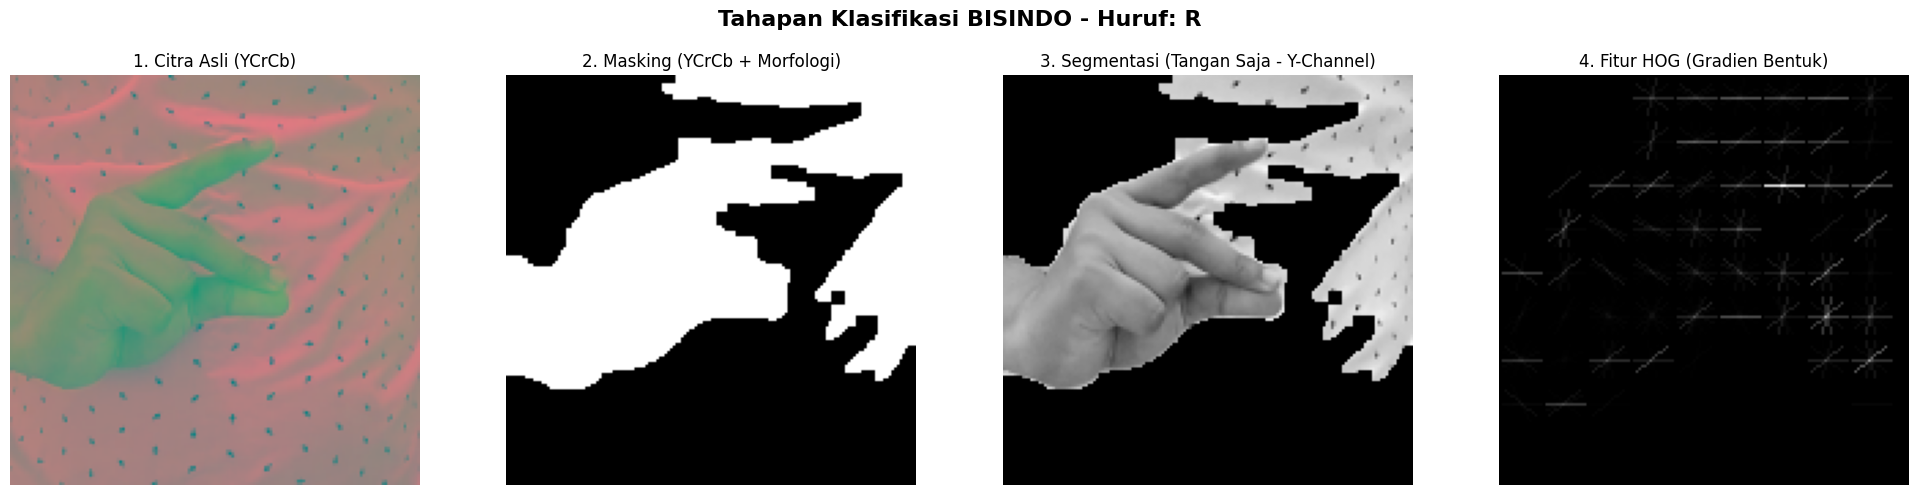

In [ ]:
def visualize_processing_steps(examples, target_label='A'):
    """
    Menampilkan visualisasi langkah demi langkah untuk satu label tertentu.
    """
    if target_label not in examples:
        # Jika label target tidak ada, ambil label pertama yang tersedia
        target_label = list(examples.keys())[0]

    data = examples[target_label]

    # Setup Figure
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(f"Tahapan Klasifikasi BISINDO - Huruf: {target_label}", fontsize=16, fontweight='bold')

    # 1. Citra Asli
    axes[0].imshow(cv2.cvtColor(data['original'], cv2.COLOR_BGR2YCrCb))
    axes[0].set_title("1. Citra Asli (YCrCb)")
    axes[0].axis('off')

    # 2. Masking YCrCb
    # Memperlihatkan hasil segmentasi warna kulit
    axes[1].imshow(data['mask'], cmap='gray')
    axes[1].set_title("2. Masking (YCrCb + Morfologi)")
    axes[1].axis('off')

    # 3. Hasil Segmentasi (Mask applied to Y-Channel of YCrCb)
    # Menggunakan 'masked_component' yang sudah merupakan saluran Y yang ter-masking
    axes[2].imshow(data['masked_component'], cmap='gray')
    axes[2].set_title("3. Segmentasi (Tangan Saja - Y-Channel)")
    axes[2].axis('off')

    # 4. Visualisasi HOG
    # Memperlihatkan arah gradien yang dideteksi
    axes[3].imshow(data['hog_image'], cmap='gray')
    axes[3].set_title("4. Fitur HOG (Gradien Bentuk)")
    axes[3].axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()

# Panggil fungsi visualisasi
# Anda bisa mengganti 'A' dengan huruf lain yang ada di dataset Anda
visualize_processing_steps(example_images, target_label='R')

In [ ]:
# --- Pembagian Data dan Scaling ---

# Pembagian data training dan testing
X_train, X_test, y_train, y_test = train_test_split(
    X_features,
    y_labels,
    test_size=TEST_SIZE,
    random_state=11,
    stratify=y_labels
)

# Standard Scaling (Wajib untuk K-NN setelah menggunakan HOG)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nData Training (setelah Scaling): {X_train_scaled.shape}")
print(f"Data Testing (setelah Scaling): {X_test_scaled.shape}")

# --- Pelatihan dan Evaluasi K-NN ---

print(f"\nMelatih Model K-NN dengan K = {K_VALUE}...")
knn_model = KNeighborsClassifier(n_neighbors=K_VALUE)
knn_model.fit(X_train_scaled, y_train)

# Prediksi
y_pred = knn_model.predict(X_test_scaled)

# Evaluasi
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, zero_division=0)

print("\n"+"="*70)
print(f"✅ AKURASI MODEL K-NN (K={K_VALUE} dengan HOG & Scaling): {accuracy*100:.2f}%")
print("="*70)
print("\nLaporan Klasifikasi:")
print(report)


Data Training (setelah Scaling): (585, 2304)
Data Testing (setelah Scaling): (65, 2304)

Melatih Model K-NN dengan K = 3...

✅ AKURASI MODEL K-NN (K=3 dengan HOG & Scaling): 86.15%

Laporan Klasifikasi:
              precision    recall  f1-score   support

           A       1.00      1.00      1.00         3
           B       0.75      1.00      0.86         3
           C       0.50      1.00      0.67         2
           D       1.00      0.50      0.67         2
           E       1.00      1.00      1.00         2
           F       1.00      1.00      1.00         2
           G       1.00      1.00      1.00         2
           H       1.00      0.67      0.80         3
           I       0.00      0.00      0.00         2
           J       0.67      1.00      0.80         2
           K       0.50      0.50      0.50         2
           L       1.00      1.00      1.00         2
           M       1.00      0.67      0.80         3
           N       0.75      1.00      


--- Prediksi Gambar (Inference) dari Dataset Uji ---


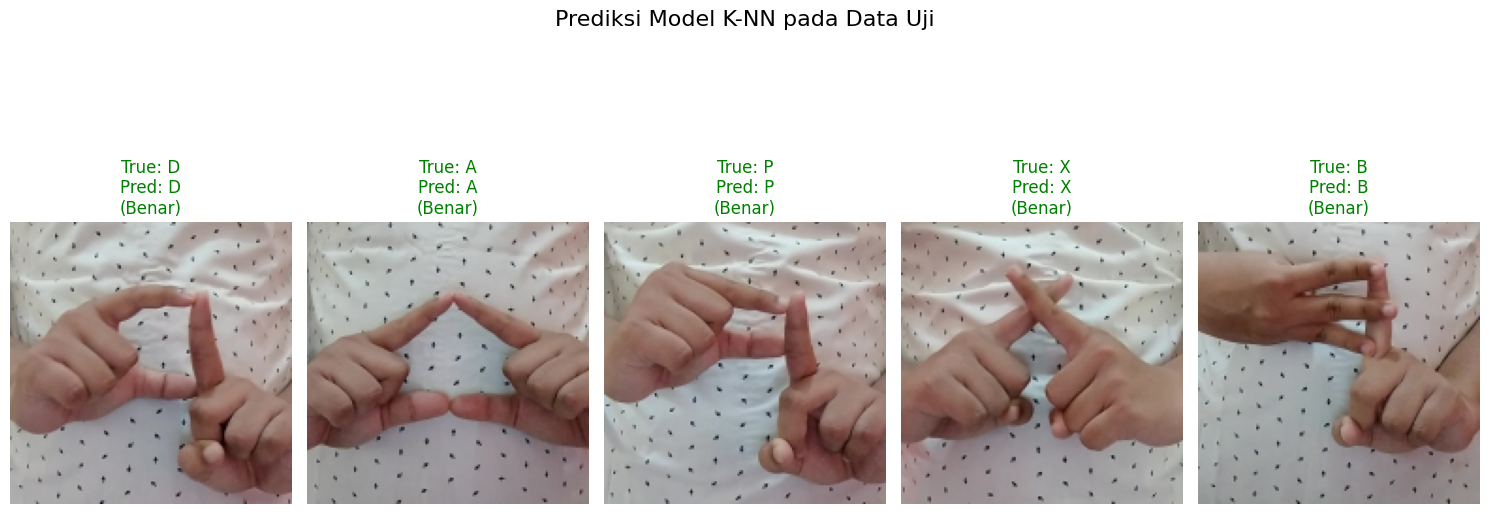

In [ ]:
print("\n--- Prediksi Gambar (Inference) dari Dataset Uji ---")

# Ambil beberapa indeks acak dari dataset uji
num_samples_to_show = 5 # Jumlah contoh yang ingin ditampilkan
random_test_indices = random.sample(range(len(X_test_scaled)), num_samples_to_show)

plt.figure(figsize=(15, 6))
plt.suptitle("Prediksi Model K-NN pada Data Uji", fontsize=16, y=1.05)

for i, idx in enumerate(random_test_indices):
    true_label = y_test[idx]
    predicted_label = y_pred[idx]
    is_correct = "Benar" if true_label == predicted_label else "Salah"

    # Dapatkan gambar contoh dari `example_images` untuk kelas sebenarnya
    # (Ini adalah gambar representatif, bukan gambar asli dari data uji yang diprediksi)
    img_to_show = None
    if true_label in example_images and 'original' in example_images[true_label]:
        img_to_show = example_images[true_label]['original']
    else:
        # Jika tidak ada di example_images, coba ambil dari kelas lain atau placeholder
        print(f"Peringatan: Gambar contoh untuk kelas {true_label} tidak ditemukan.\n")
        # Buat gambar placeholder hitam jika tidak ada gambar contoh
        img_to_show = np.zeros((IMG_SIZE[0], IMG_SIZE[1], 3), dtype=np.uint8)

    plt.subplot(1, num_samples_to_show, i + 1)
    plt.imshow(cv2.cvtColor(img_to_show, cv2.COLOR_BGR2RGB))
    plt.title(f"True: {true_label}\nPred: {predicted_label}\n({is_correct})",
              color='green' if is_correct == "Benar" else 'red')
    plt.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


Saving body dot (1) (2).jpg to body dot (1) (2).jpg
Saving body dot (1) (1).jpg to body dot (1) (1) (1).jpg
Saving body dot (1).jpg to body dot (1) (3).jpg


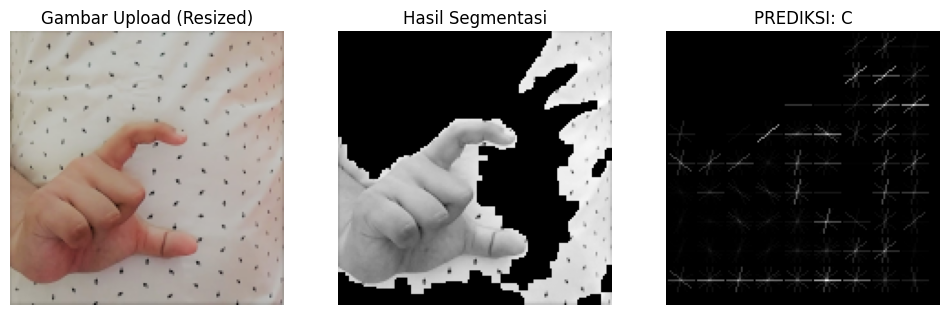

Hasil Prediksi untuk body dot (1) (2).jpg: Huruf C


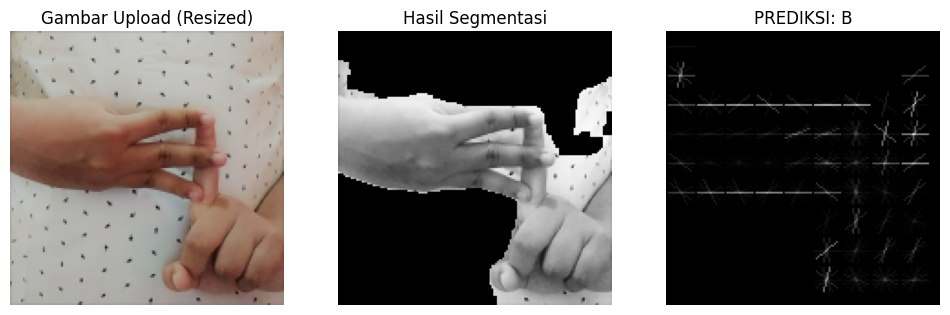

Hasil Prediksi untuk body dot (1) (1) (1).jpg: Huruf B


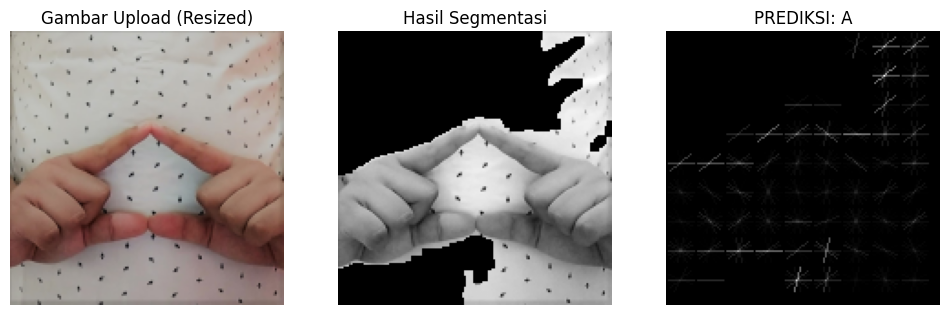

Hasil Prediksi untuk body dot (1) (3).jpg: Huruf A


In [ ]:
from google.colab import files
import io

def predict_uploaded_image():
    # 1. Upload File
    uploaded = files.upload()

    if not uploaded:
        print("Tidak ada file yang dipilih.")
        return

    for filename in uploaded.keys():
        # 2. Baca Gambar
        file_bytes = np.frombuffer(uploaded[filename], np.uint8)
        img = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)

        if img is None:
            print(f"Gagal membaca file {filename}")
            continue

        # 3. Preprocessing & Segmentasi (Sesuai alur training)
        resized_img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)

        # Panggil fungsi segmentasi YCrCb yang sudah Anda buat
        mask = segment_skin_color(resized_img)

        # Ambil channel Y dan masking
        ycrcb_img = cv2.cvtColor(resized_img, cv2.COLOR_BGR2YCrCb)
        y_channel = ycrcb_img[:,:,0]
        masked_component = cv2.bitwise_and(y_channel, y_channel, mask=mask)

        # 4. Ekstraksi Fitur HOG
        features, hog_img = hog(
            masked_component,
            orientations=ORIENTATIONS,
            pixels_per_cell=PIXELS_PER_CELL,
            cells_per_block=CELLS_PER_BLOCK,
            visualize=True,
            transform_sqrt=True
        )

        # 5. Scaling & Prediksi
        # Fitur harus di-reshape menjadi (1, n_features) dan di-scale menggunakan scaler yang sama
        features_scaled = scaler.transform(features.reshape(1, -1))
        prediction = knn_model.predict(features_scaled)[0]

        # 6. Tampilkan Hasil
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 3, 1)
        plt.imshow(cv2.cvtColor(resized_img, cv2.COLOR_BGR2RGB))
        plt.title("Gambar Upload (Resized)")
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.imshow(masked_component, cmap='gray')
        plt.title("Hasil Segmentasi")
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.imshow(hog_img, cmap='gray')
        plt.title(f"PREDIKSI: {prediction}")
        plt.axis('off')

        plt.show()
        print(f"Hasil Prediksi untuk {filename}: Huruf {prediction}")

# Jalankan fungsi prediksi
predict_uploaded_image()